In [2]:
#Import packages
#---------------------------------------
import sys
import os
import glob
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import matplotlib
import kedm
import warnings
import gc
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#Import your modules
#---------------------------------------
import CCM as cfn
import proc_functions as pfn

sys.path.insert(0, os.path.expanduser('~/Documents/admin_tools'))
from admin_tools import admin_functions as adfn

# Define paths
#----------------------------------------------------------------------
code_path = '~/Documents/empirical_dynamic_modelling'
data_path = '/snl/scratch25/dburrows/CCM'

%load_ext autoreload
sys.version

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'3.7.4 (default, Aug 13 2019, 20:35:49) \n[GCC 7.3.0]'

# Load in data

In [24]:
#group data
#================
#group by sample
xmap_l = np.asarray([os.path.basename(i) for i in np.sort(glob.glob(data_path + '/*xmap*'))])

import re
bln = xmap_l[[bool(re.search(r'(BLN|PTZ05)', i)) for i in xmap_l]]
ptz20 = xmap_l[[bool(re.search(r'(PTZ20)', i)) for i in xmap_l]]

#filter out 12 pre
s = pd.Series(ptz20)  # your series
mask = ~(s.str.contains(r'-12', na=False) & s.str.contains(r'pre', na=False))   # case-sensitive
ptz20 = ptz20[mask]

#unique sample list 
unq_l = np.append(np.unique(np.asarray([re.search(r'^(.*?_run-01)', i).group(1) for i in bln])),
          np.unique(np.asarray([''.join(re.search(r'^(.*?_run-01)(.{4})', i).groups()) for i in ptz20])))

In [39]:
# mask data
%autoreload
#Compute fraction of cells that converge, and mean CCM in convergent cells
#==========================================================
from tqdm import tqdm

#parameters
n_int = 3 #expected interval files
int_l=[1.2, 1.4, 1.8] #expected intervals - make sure numbers are complete as in string! 
# -0.2 - i.e. allow a single negative value with <20% of the mean positive increase, to be convergent
ratio_val = -0.2 

results = []
# Loop through each unique base name
for curr in tqdm(unq_l, desc='Processing CCM files'):
    curr_l = glob.glob(f'{data}/{curr}*xmap*')
    og, mask, conv_arr = pfn.conv_check(curr_l=curr_l, n_int=n_int, int_l=int_l, ratio_val=ratio_val)
    np.save(f'{data}/{curr}_xmap_mask.npy', mask)

Processing CCM files: 100%|████████████████████████████████████████████████████████████████████████████████████████| 28/28 [06:57<00:00, 14.92s/it]


In [63]:
#estimate correlation coefficient
from tqdm import tqdm
for string in tqdm(trace_l, 'files'):
    out = string.split('_')[:-1]
    name ='_'.join(out)
    trace = np.load(f'{name}_regtrace.npy')
    
    if 'run-01_sz' in name: coord = np.load(f"{name.replace('sz','')}labcoord.npy")
    elif 'run-01_pre' in name: coord = np.load(f"{name.replace('pre','')}labcoord.npy")
    else: coord = np.load(f'{name}_labcoord.npy')
    
    trace = trace[coord[:,4] != 'nan']
    corr = np.corrcoef(trace)
    np.save(f'{name}_corr.npy', corr)

files: 100%|


In [2]:
%autoreload
#load mask, trace & coords
#====ƒ===========================
trace_l = np.sort(glob.glob(f'{data_path}/*regtrace*'))
xmap_l = np.sort(glob.glob(f'{data_path}/*_CCMxmap*'))
mask_l = np.sort(glob.glob(f'{data_path}/*mask*'))
coord_l = np.sort(glob.glob(f'{data_path}/*labcoord*'))

#load current into dic
dic = cfn.xtr(mask_l[0])
dic

{'name': 'PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01',
 'trace': array([[1101.0016   ,  375.2699   ,  160.53424  , ...,  563.22595  ,
          127.223816 ,  208.07672  ],
        [ 454.70795  , 1038.5254   ,  936.5166   , ...,  417.1315   ,
          353.54297  ,  175.36679  ],
        [   1.2036324,  610.8864   ,   23.124939 , ...,   86.47761  ,
          347.2641   ,   28.184055 ],
        ...,
        [ 151.80298  ,   44.495804 ,    1.4848621, ...,   79.7669   ,
           19.013315 ,  224.81856  ],
        [  10.489203 ,    4.8878937,   81.60853  , ...,   20.048714 ,
           11.057799 ,   17.846321 ],
        [   9.782074 ,   33.105247 ,  475.08185  , ...,   32.403248 ,
          157.73413  ,   37.58297  ]], dtype=float32),
 'coord': array([['355.94736842105266', '435.0', '97.52631578947368',
         'Optic tectum - stratum periventriculare', 'Midbrain'],
        ['409.8125', '569.8125', '132.25', 'Rhombomere 3 - Dorsolateral',
         'Hindbrain'],
        ['459.375', '

In [ ]:
#directionality
#rows = each cell is the effects of the current row
#columns = each cell is the causes of the current column
#(ie. cell xy = to what extent does x cause y; cell yx = to what extent does y cause x). 

# Coarse network analysis

In [86]:
%autoreload
from tqdm import tqdm
import pickle
#estimate rho and convergence fraction across all datasets
for i in tqdm(mask_l):
    dic = cfn.xtr(i)
    new_dic = {'name': dic['name']}
    mask = dic['mask']
    xmap = dic['xmap']
    labels = dic['coord'][:,3]
    regions, xmap_m, std_m, conv_m = cfn.ccm_region(mask=mask, xmap=xmap, labels=labels)
    new_dic.update({'granular': 
              {
               'regions': regions,
               'rho': xmap_m,
               'std': std_m,
               'conv': conv_m
              }
              })

    labels = dic['coord'][:,4]
    regions, xmap_m, std_m, conv_m = cfn.ccm_region(mask=mask, xmap=xmap, labels=labels)
    new_dic.update({'coarse': 
              {
               'regions': regions,
               'rho': xmap_m,
               'std': std_m,
               'conv': conv_m
              }

              })
    with open(f"{data_path}/{new_dic['name']}_region_stats.pkl", "wb") as f:
        pickle.dump(new_dic, f)

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [10:15<00:00, 21.99s/it]


In [ ]:
# generate csv - per sample, per region-region, value

In [6]:
from tqdm import tqdm
import pickle

#====================
#Flow across regions
#====================

#extract all data
#==================
def do(dic, mode):
    curr = dic['reg_stats'][mode]
    rho = np.ravel(curr['rho'])
    pairs = np.ravel([np.core.defchararray.add(i + '-', curr['regions']) for i in curr['regions']])
    
    name = np.repeat(dic['name'],len(rho))
    
    if 'BLN' in dic['name']: cond = 'BLN'
    elif 'PTZ05' in dic['name']: cond = 'PTZ05'
    elif 'pre' in dic['name']: cond = 'pre'
    elif 'sz' in dic['name']: cond = 'sz'
    else: cond = 'NA'
    cond = np.repeat(cond, len(rho))
    scale = np.repeat(mode, len(rho))
    return(name, pairs, scale, cond, rho)


#loop through each dataset and scale
rows = []
for i in tqdm(mask_l):
    dic = cfn.xtr(i)
    with open(f'{data_path}/{dic["name"]}_region_stats.pkl', "rb") as f: data = pickle.load(f)
    dic.update({'reg_stats': data})
    
    for scale in ('coarse', 'granular'):
        name, pairs, scale_arr, cond, rho = do(dic, scale)
        rows.append(pd.DataFrame({
            'name':  name,
            'pair':  pairs,
            'scale': scale_arr,
            'cond':  cond,
            'rho':   rho,
        }))
df = pd.concat(rows, ignore_index=True)
df['driver'] = [i.split('-')[0] for i in df['pair'].values]
df['driven'] = [i.split('-')[1] for i in df['pair'].values]

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:25<00:00,  1.08it/s]


In [35]:
dic['reg_stats']

{'name': 'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run-01',
 'granular': {'regions': array(['!', 'Anterior commissure', 'Cerebellar neuropil',
         'Corpus cerebelli', 'Eminentia granularis', 'Griseum tectale',
         'Habenula', 'Hypothalamus - Intermediate Zone',
         'Hypothalamus - Rostral Zone', 'Inferior raphe',
         'Interpeduncular nucleus tegmentum', 'Locus coeruleus',
         'Mauthner neuron', 'Medial tectal band',
         'Medial vestibular nucleus',
         'Medulla oblongata - Anterior ventral',
         'Medulla oblongata - Rostrolateral domain', 'Mesencephalon',
         'Migrated posterior tubercular area M2',
         'Migrated pretectal area M1', 'NucMLF', 'Olfactory bulb',
         'Olfactory epithelium', 'Optic tectum - neuropil',
         'Optic tectum - stratum periventriculare', 'Optic tract - AF2',
         'Optic tract - AF4', 'Optic tract - AF9', 'Pallium',
         'Pineal complex', 'Posterior tuberculum', 'PosteriorTuberculum',
         '

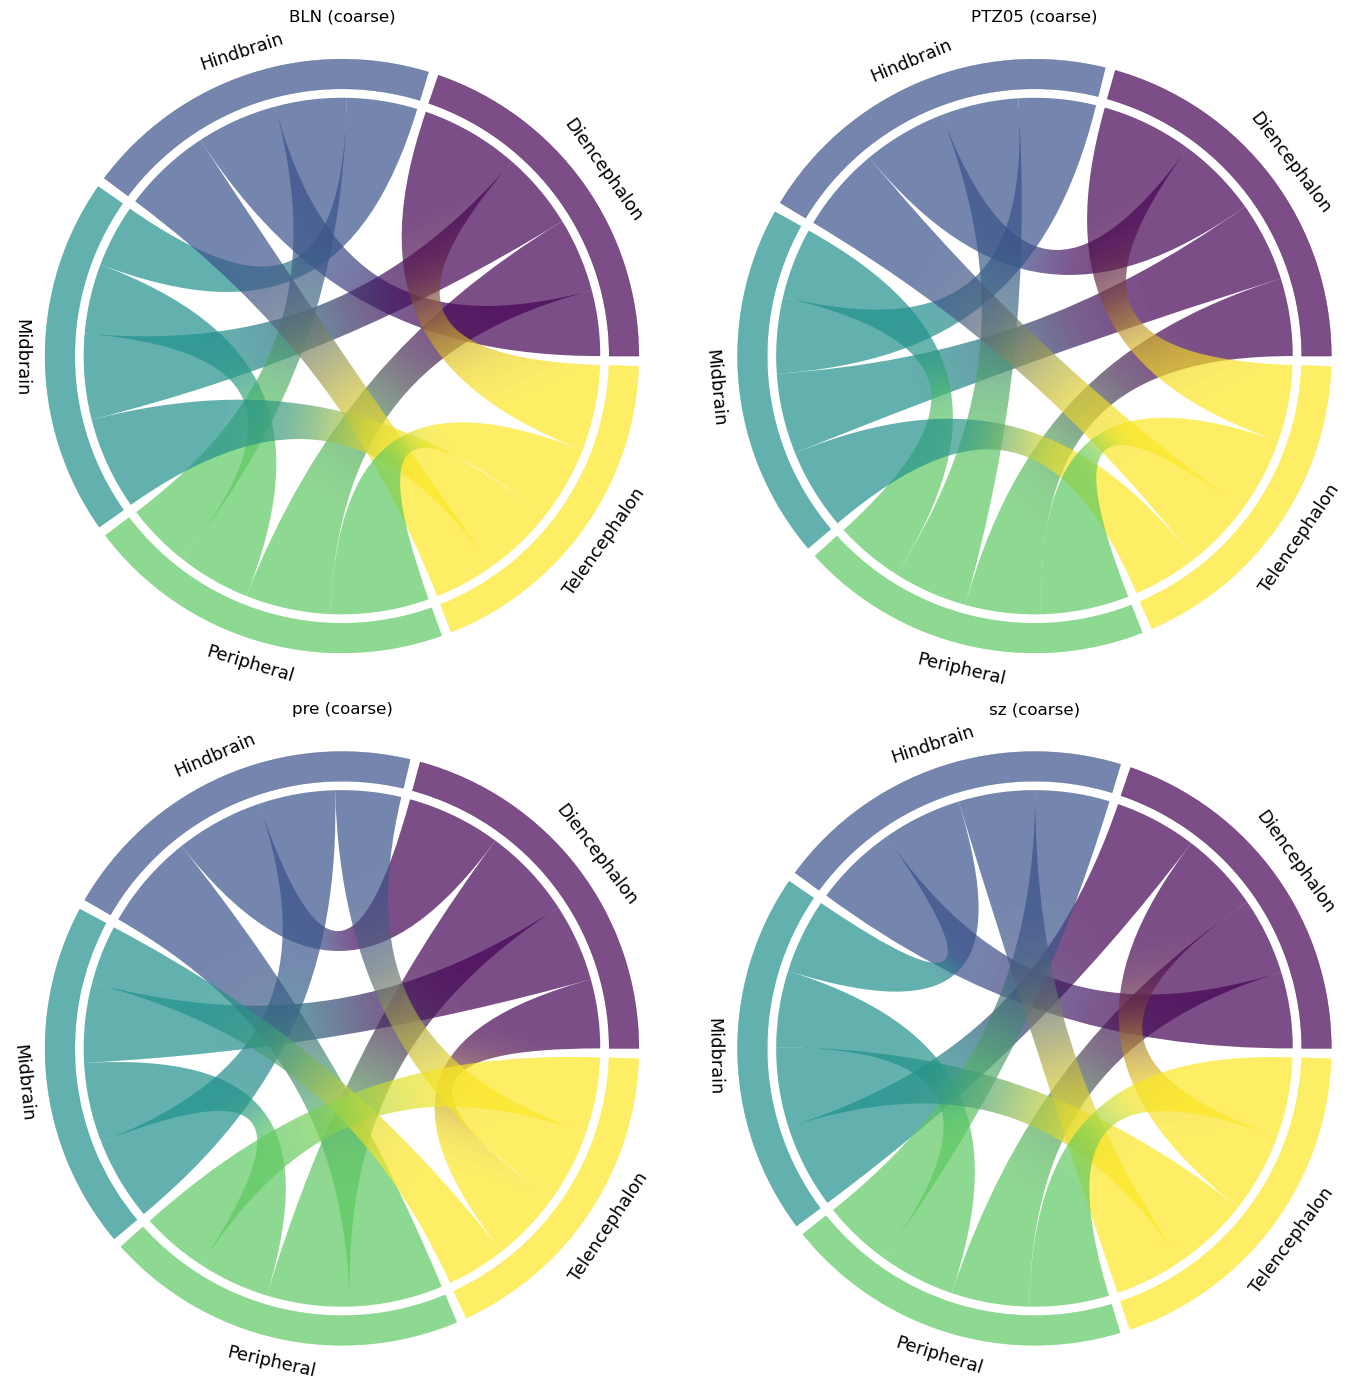

In [18]:
#COARSE GRAINED ANALYSES
#=========================

import numpy as np
import matplotlib.pyplot as plt
from mpl_chord_diagram import chord_diagram

conds = ["BLN", "PTZ05", "pre", "sz"]
scale_sel = "coarse"
drop_label = "Unspecified"
quantile_keep = 0.0   # top 80% keep, computed *globally*

# Filter once; fix node order globally
df_use = df[
    (df["scale"] == scale_sel) &
    (df["driver"] != drop_label) &
    (df["driven"] != drop_label)
].copy()

nodes = sorted(set(df_use["driver"]).union(df_use["driven"]))
idx = {n: i for i, n in enumerate(nodes)}

# ---- Global normalization + (optional) global threshold ----
rho_max = df_use["rho"].max()  # common scale for ribbon thickness
# Use same quantile across all panels (exclude self-links when computing)
global_thr = (df_use[df_use["driver"] != df_use["driven"]]["rho"]
              .quantile(quantile_keep))

# 2×2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 14), subplot_kw={'aspect': 'equal'})
axes = axes.ravel()

for ax, cond in zip(axes, conds):
    sub = df_use[df_use["cond"] == cond]
    agg = sub.groupby(["driver", "driven"], as_index=False)["rho"].mean()
    agg = agg[agg["driver"] != agg["driven"]]

    # apply *global* threshold so panels are comparable
    agg = agg[agg["rho"] >= global_thr]

    # Build adjacency, then normalize by global max so thickness is comparable
    M = np.zeros((len(nodes), len(nodes)), dtype=float)
    for _, r in agg.iterrows():
        M[idx[r["driver"]], idx[r["driven"]]] = r["rho"] / (rho_max + 1e-12)

    chord_diagram(
        M,
        names=nodes,
        use_gradient=True,
        chordwidth=0.7,
        rotate=0,
        ax=ax,
        show=False
    )
    ax.set_title(f"{cond} ({scale_sel})", fontsize=12)

plt.tight_layout()
plt.show()

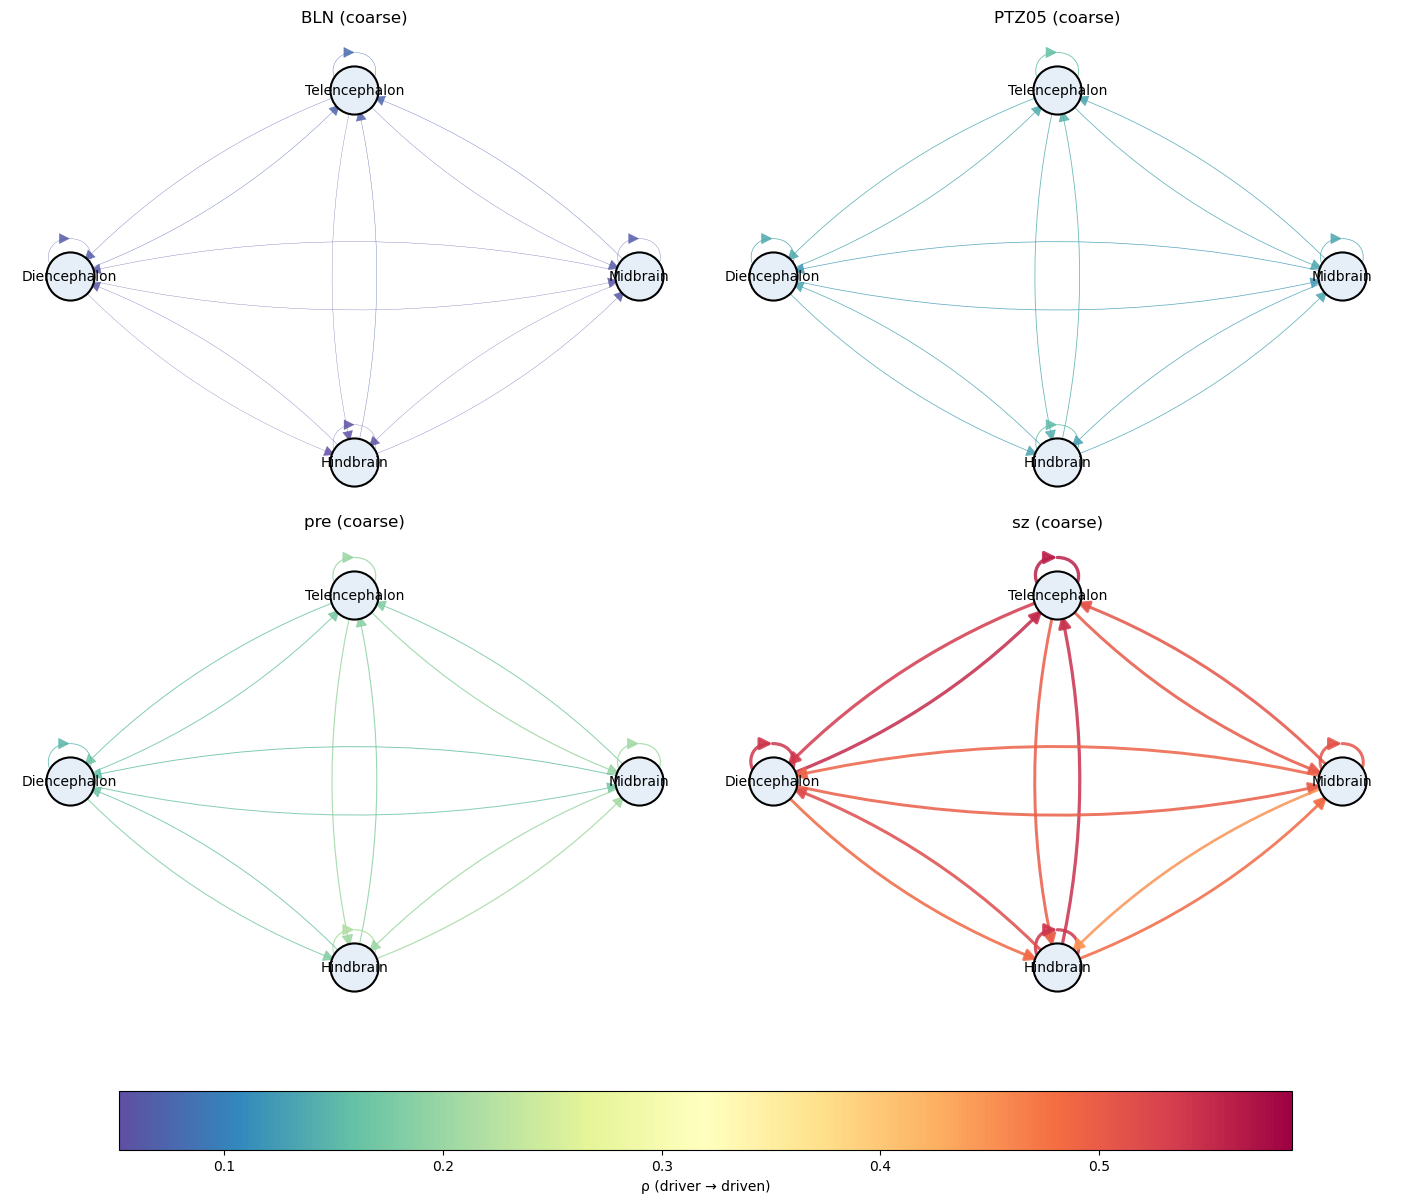

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx

conds = ["BLN", "PTZ05", "pre", "sz"]
scale_sel = "coarse"

pos_fixed = {
    "Telencephalon": (0.0,  1.0),
    "Hindbrain":     (0.0, -1.0),
    "Diencephalon": (-1.0,  0.0),
    "Midbrain":      (1.0,  0.0)}
nodes = list(pos_fixed.keys())

# global scaling
all_w = []
for c in conds:
    M = M_dict[c]
    if M.size:
        all_w.extend(M[M > 0].ravel())
if not all_w:
    all_w = [0.0]

vmin, vmax = float(np.min(all_w)), float(np.max(all_w))
if vmax <= 0:
    vmax = 1.0

cmap = plt.cm.Spectral_r
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, cond in zip(axes, conds):
    M = M_dict[cond]

    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    for i, drv in enumerate(nodes):
        for j, drn in enumerate(nodes):
            w = float(M[i, j])
            if w > 0:
                G.add_edge(drv, drn, weight=w)

    edges = list(G.edges())
    weights = np.array([G[u][v]["weight"] for u, v in edges], dtype=float)

    if weights.size:
        colors = cmap(norm(weights))
        widths = 2.5 * (weights / vmax)
    else:
        colors, widths = [], []

    # --- draw nodes (below) ---
    nx.draw_networkx_nodes(
        G, pos_fixed, ax=ax,
        node_size=1200,
        node_color="#e6eef7",
        edgecolors="black",
        linewidths=1.5
    )
    nx.draw_networkx_labels(
        G, pos_fixed, ax=ax,
        font_size=10, font_color="black"
    )

    # --- draw edges (arrowheads on top) ---
    nx.draw_networkx_edges(
        G, pos_fixed, ax=ax,
        edge_color=colors,
        width=widths.tolist(),
        arrows=True, arrowsize=18,
        arrowstyle='-|>',         # clean arrowhead
        min_target_margin=15,     # gap so arrowhead visible
        connectionstyle="arc3,rad=0.12",
        alpha=0.85
    )

    ax.set_title(f"{cond} ({scale_sel})")
    ax.set_axis_off()

# colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.06, pad=0.08)
cbar.set_label("ρ (driver → driven)")

plt.show()

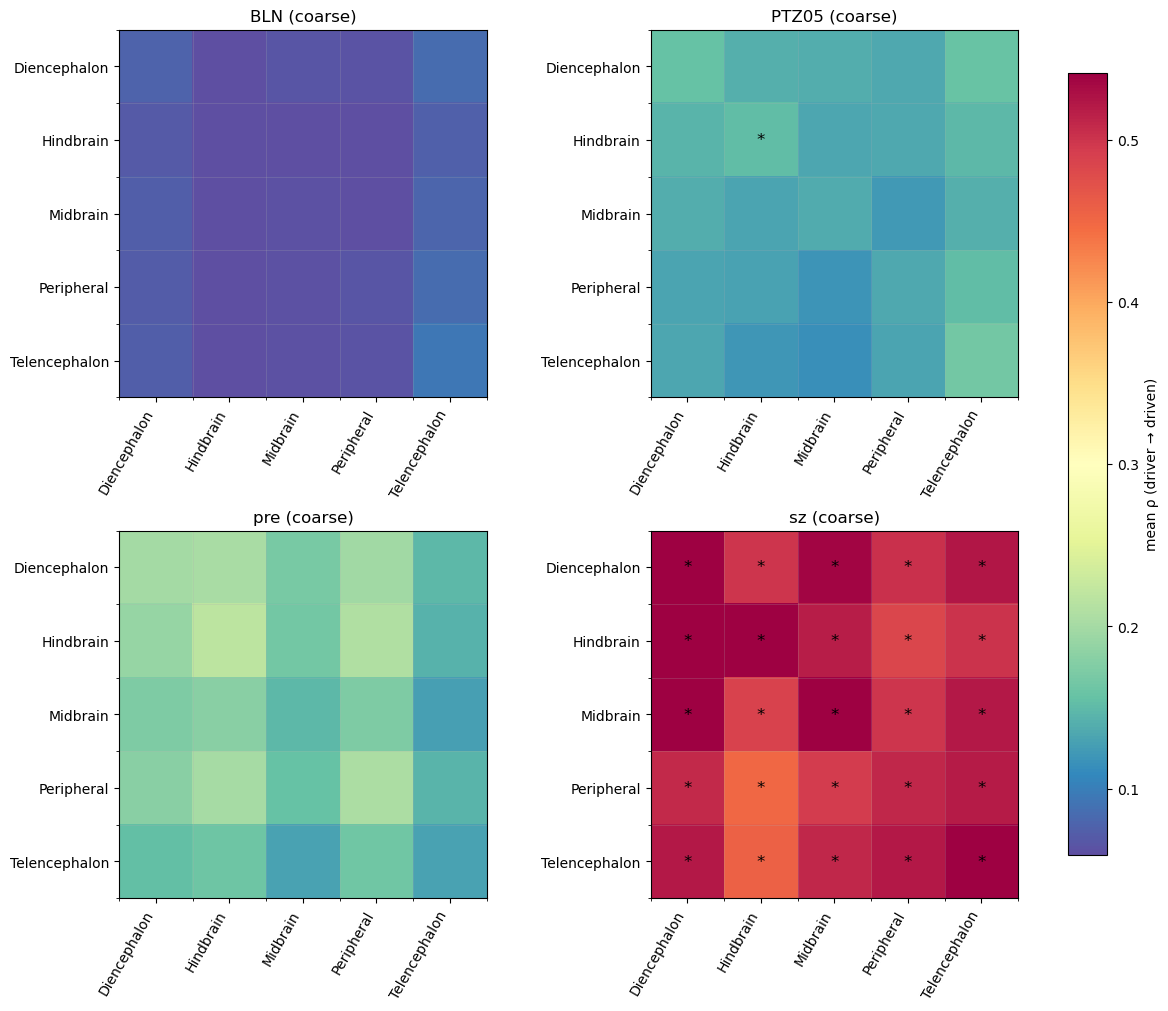

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# --- config ---
conds = ["BLN", "PTZ05", "pre", "sz"]
scale_sel = "coarse"
drop_label = "Unspecified"
alpha = 0.05
mask_diag = False

# 1) Filter and fix nodes
df_use = df[
    (df["scale"] == scale_sel) &
    (df["driver"] != drop_label) &
    (df["driven"] != drop_label)
].copy()

nodes = sorted(set(df_use["driver"]).union(df_use["driven"]))
idx = {n:i for i,n in enumerate(nodes)}
R = len(nodes)

# mean rho per dataset to form group samples per edge
g = (df_use.groupby(["name","cond","driver","driven"], as_index=False)["rho"].mean())

# Build per-condition matrices (for plotting)
M_dict = {}
for cond in conds:
    sub = (df_use[df_use["cond"] == cond]
           .groupby(["driver","driven"], as_index=False)["rho"].mean())
    M = np.zeros((R,R), float)
    for _, r in sub.iterrows():
        M[idx[r["driver"]], idx[r["driven"]]] = r["rho"]
    if mask_diag:
        np.fill_diagonal(M, np.nan)
    M_dict[cond] = M

# Common color scale
all_vals = np.concatenate([np.ravel(M_dict[c]) for c in conds])
all_vals = all_vals[~np.isnan(all_vals)]
vmin, vmax = np.percentile(all_vals, [5,95]) if all_vals.size else (0,1)

# 2) Independent-sample tests vs BLN, Bonferroni correction
tests = ["PTZ05","pre","sz"]
sig_masks = {c: np.full((R,R), False, bool) for c in tests}

for test_cond in tests:
    pmat = np.full((R,R), np.nan, float)
    incmat = np.full((R,R), np.nan, float)

    # collect all p-values first (to know number of tests for Bonferroni)
    pvals = []

    for i, drv in enumerate(nodes):
        for j, drn in enumerate(nodes):
            if mask_diag and i == j:
                continue

            bln_vals = g[(g["cond"]=="BLN") & (g["driver"]==drv) & (g["driven"]==drn)]["rho"].to_numpy()
            tst_vals = g[(g["cond"]==test_cond) & (g["driver"]==drv) & (g["driven"]==drn)]["rho"].to_numpy()

            # need a few samples in each group to test
            if len(bln_vals) < 3 or len(tst_vals) < 3:
                continue

            stat, p = mannwhitneyu(tst_vals, bln_vals, alternative="greater")
            pmat[i,j] = p
            incmat[i,j] = np.nanmean(tst_vals) - np.nanmean(bln_vals)
            pvals.append(p)

    # Bonferroni threshold uses number of actually-tested edges
    m = len(pvals)
    thr = alpha / m if m > 0 else 0.0

    # significant = p < alpha/m AND mean increase > 0
    sig = (pmat < thr) & (incmat > 0)
    sig_masks[test_cond] = np.nan_to_num(sig, nan=False)

# 3) Plot heatmaps with Bonferroni-significant increases marked
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axes = axes.ravel()

for ax, cond in zip(axes, conds):
    M = M_dict[cond]
    im = ax.imshow(M, vmin=vmin, vmax=vmax, aspect="equal", cmap="Spectral_r")
    ax.set_title(f"{cond} ({scale_sel})")
    ax.set_xticks(range(R)); ax.set_xticklabels(nodes, rotation=60, ha="right")
    ax.set_yticks(range(R)); ax.set_yticklabels(nodes)
    ax.set_xticks(np.arange(-.5,R,1), minor=True)
    ax.set_yticks(np.arange(-.5,R,1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5, alpha=0.3)

    if cond in sig_masks:
        ys, xs = np.where(sig_masks[cond])
        for y, x in zip(ys, xs):
            ax.text(x, y, "*", ha="center", va="center", fontsize=12, color="k")

cbar = fig.colorbar(im, ax=axes, shrink=0.9)
cbar.set_label("mean ρ (driver → driven)")
plt.show()


In [28]:
#figure out network visualisation figure

,name,rho_bln,rho_tst


In [27]:
#figure out in vs out hubs

,name,rho
74,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run...,0.453822
99,PTZ-WILDTYPE-04_2photon_sess-01-6dpf_PTZ20_run...,0.541327
224,PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run...,0.569837
274,PTZ-WILDTYPE-08_2photon_sess-01-6dpf_PTZ20_run...,0.394154
399,PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ20_run...,0.755794
474,PTZ-WILDTYPE-12_2photon_sess-01-6dpf_PTZ20_run...,0.753804
649,PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run...,0.649869


In [ ]:
#figure out network topology

In [ ]:
#GRANULAR ANALYSES
#=========================

# Non-linearity & dimensionality

In [119]:
from tqdm import tqdm
%autoreload
#extract E/rhodiff per region + condition
#=======================================
fin = pd.DataFrame()
for data in tqdm(mask_l):
    dic = cfn.xtr(data)
    
    df=pd.DataFrame({'E':dic['E'], 'coarse':dic['coord'][:,4], 'gran':dic['coord'][:,3]})
    #E into df
    coarse = df.drop(columns='gran').groupby(['coarse']).mean().reset_index().rename(columns={"coarse": "region"}).assign(label="coarse")
    gran = df.drop(columns='coarse').groupby(['gran']).mean().reset_index().rename(columns={"gran": "region"}).assign(label="gran")
    comb = pd.concat([coarse,gran])

    if '_sz_' in data or '_pre_' in data:
        cond = data.split('_')[-2]
    else:
        cond = data.split('_')[-3]

    comb['name'] = cond
    comb['id'] = os.path.basename(data)
    fin=pd.concat([fin,comb])
    
fin.to_csv(f'{data_path}/E_region.csv')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [01:34<00:00,  3.39s/it]


In [3]:
df = pd.read_csv(f'{data_path}/E_region.csv')

In [4]:
df

,Unnamed: 0,region,E,label,name,id
0,0,Diencephalon,15.588838,coarse,BLN,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-0...
1,1,Hindbrain,15.160334,coarse,BLN,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-0...
2,2,Midbrain,15.510391,coarse,BLN,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-0...
3,3,Peripheral,15.939467,coarse,BLN,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-0...
4,4,Telencephalon,16.573854,coarse,BLN,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-0...
...,...,...,...,...,...,...
2356,65,Trigeminal motor neurons - anterior,15.312500,gran,PTZ05,PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run...
2357,66,Valvula cerebelli,15.813167,gran,PTZ05,PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run...
2358,67,Ventral thalamus,16.071038,gran,PTZ05,PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run...
2359,68,VentralThalamus,16.868182,gran,PTZ05,PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run...


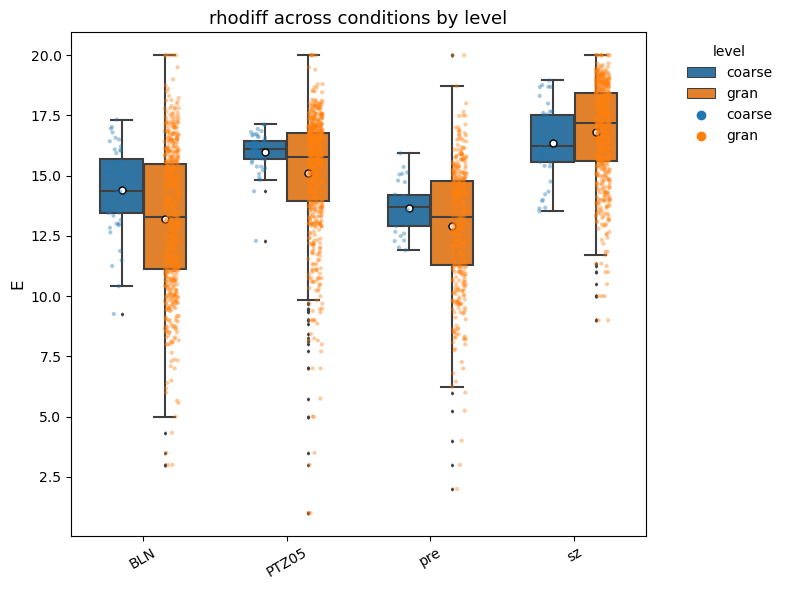

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure order consistency

order_cond = sorted(df['name'].unique())
order_level = sorted(df['label'].unique())

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='name', y='E',
    hue='label',
    order=order_cond,
    hue_order=order_level,
    fliersize=1.5,
    width=0.6,
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 5}
)

sns.stripplot(
    data=df,
    x='name', y='E',
    hue='label',
    dodge=True,
    order=order_cond,
    hue_order=order_level,
    size=3, alpha=0.4
)

plt.xlabel('')
plt.ylabel('E', fontsize=12)
plt.title('rhodiff across conditions by level', fontsize=13)
plt.xticks(rotation=30)
plt.legend(title='level', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()


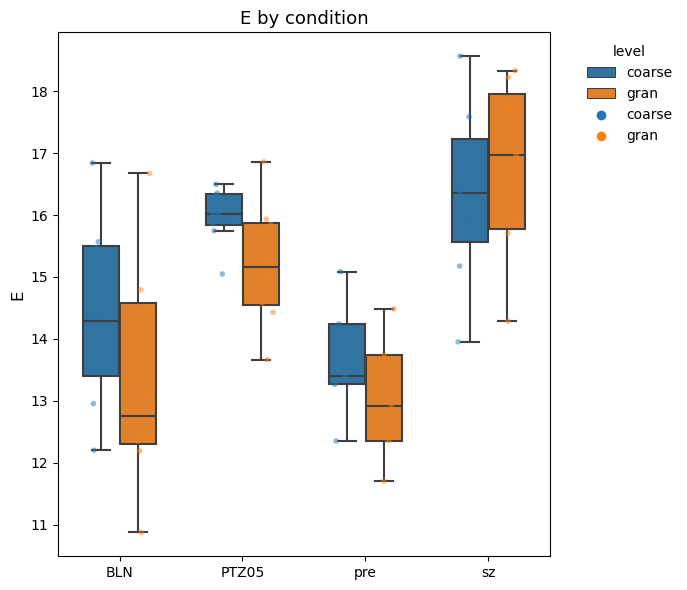


Significance vs BLN (two-sample t-test):

  coarse: PTZ05  vs BLN -> p = 0.0213
  coarse: pre    vs BLN -> p = 0.3269
  coarse: sz     vs BLN -> p = 0.0279
    gran: PTZ05  vs BLN -> p = 0.0312
    gran: pre    vs BLN -> p = 0.6990
    gran: sz     vs BLN -> p = 0.0019

Variance of E by condition and label:

  coarse: BLN    -> var = 2.3020
  coarse: PTZ05  -> var = 0.2089
  coarse: pre    -> var = 1.0752
  coarse: sz     -> var = 2.3322
    gran: BLN    -> var = 3.4134
    gran: PTZ05  -> var = 1.0095
    gran: pre    -> var = 1.2075
    gran: sz     -> var = 2.2610

Significance vs BLN (two-sample t-test):

  coarse: PTZ05  vs BLN -> p = 0.0213
  coarse: pre    vs BLN -> p = 0.3269
  coarse: sz     vs BLN -> p = 0.0279
    gran: PTZ05  vs BLN -> p = 0.0312
    gran: pre    vs BLN -> p = 0.6990
    gran: sz     vs BLN -> p = 0.0019


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# average over regions (one value per id x condition x level)
df_avg = df.groupby(['id', 'name', 'label'], as_index=False)['E'].mean()

# specify condition order
order_cond = ['BLN', 'PTZ05', 'pre', 'sz']
order_label = sorted(df_avg['label'].unique())

# --- Plot ---
plt.figure(figsize=(7,6))

sns.boxplot(
    data=df_avg,
    x='name', y='E',
    hue='label',
    order=order_cond,
    hue_order=order_label,
    showfliers=False, width=0.6
)
sns.stripplot(
    data=df_avg,
    x='name', y='E',
    hue='label',
    order=order_cond,
    hue_order=order_label,
    dodge=True, size=4, alpha=0.5
)

plt.xlabel('')
plt.ylabel('E', fontsize=12)
plt.title('E by condition', fontsize=13)
plt.legend(title='level', bbox_to_anchor=(1.05,1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

# --- Significance vs BLN ---
print("\nSignificance vs BLN (two-sample t-test):\n")

for lvl in df_avg['label'].unique():
    bln_vals = df_avg.loc[(df_avg['label']==lvl) & (df_avg['name']=='BLN'), 'E']
    for cond in order_cond:
        if cond == 'BLN':
            continue
        cond_vals = df_avg.loc[(df_avg['label']==lvl) & (df_avg['name']==cond), 'E']
        if len(cond_vals) > 1 and len(bln_vals) > 1:
            t, p = ttest_ind(cond_vals, bln_vals, equal_var=False)
            print(f"{lvl:>8s}: {cond:<6s} vs BLN -> p = {p:.4f}")

            
print("\nVariance of E by condition and label:\n")

# compute and print variance for each group
var_df = (
    df_avg.groupby(['label', 'name'])['E']
    .var()
    .reset_index()
    .sort_values(['label', 'name'])
)

for _, row in var_df.iterrows():
    print(f"{row['label']:>8s}: {row['name']:<6s} -> var = {row['E']:.4f}")

# --- Significance vs BLN ---
print("\nSignificance vs BLN (two-sample t-test):\n")

for lvl in df_avg['label'].unique():
    bln_vals = df_avg.loc[(df_avg['label']==lvl) & (df_avg['name']=='BLN'), 'E']
    for cond in order_cond:
        if cond == 'BLN':
            continue
        cond_vals = df_avg.loc[(df_avg['label']==lvl) & (df_avg['name']==cond), 'E']
        if len(cond_vals) > 1 and len(bln_vals) > 1:
            t, p = ttest_ind(cond_vals, bln_vals, equal_var=False)
            print(f"{lvl:>8s}: {cond:<6s} vs BLN -> p = {p:.4f}")


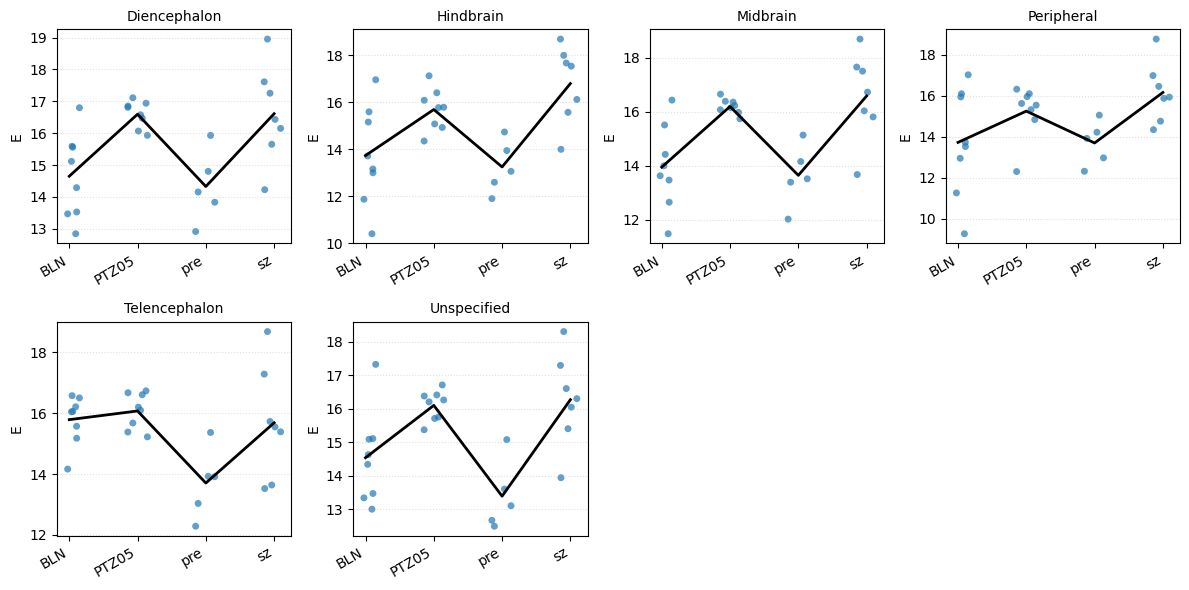

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_E_by_label(df, label_type='coarse', figsize_base=(3, 3)):
    """
    Plot embedding dimension (E) for each region (subplot)
    grouped by 'name', with each unique id as a point.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain ['region', 'E', 'label', 'name', 'id']
    label_type : str
        Either 'coarse' or 'gran' (filters df['label'])
    figsize_base : tuple
        Base size per subplot, scaled automatically
    """
    df_sub = df[df['label'] == label_type].copy()
    regions = sorted(df_sub['region'].unique())
    names = sorted(df_sub['name'].unique())

    n_regions = len(regions)
    ncols = 4 if label_type == 'coarse' else 8  # wider grid for granular view
    nrows = math.ceil(n_regions / ncols)

    fig, axes = plt.subplots(
        nrows, ncols, 
        figsize=(figsize_base[0] * ncols, figsize_base[1] * nrows),
        squeeze=False
    )

    for i, region in enumerate(regions):
        ax = axes.flat[i]
        sub = df_sub[df_sub['region'] == region]
        # slight jitter for overlapping points
        rng = np.random.default_rng(0)
        xvals = sub['name'].map({n: i for i, n in enumerate(names)})
        jitter = rng.uniform(-0.15, 0.15, size=len(xvals))
        ax.scatter(xvals + jitter, sub['E'], s=25, alpha=0.7, edgecolors='none')

        # overlay mean per name
        means = sub.groupby('name')['E'].mean().reindex(names)
        ax.plot(range(len(names)), means.values, color='black', lw=2)

        ax.set_title(region, fontsize=10)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=30, ha='right')
        ax.grid(axis='y', linestyle=':', alpha=0.4)
        ax.set_ylabel('E')

    # hide unused axes
    for j in range(i + 1, nrows * ncols):
        fig.delaxes(axes.flat[j])

    plt.tight_layout()
    plt.show()


# Example usage:
plot_E_by_label(fin, label_type='coarse')

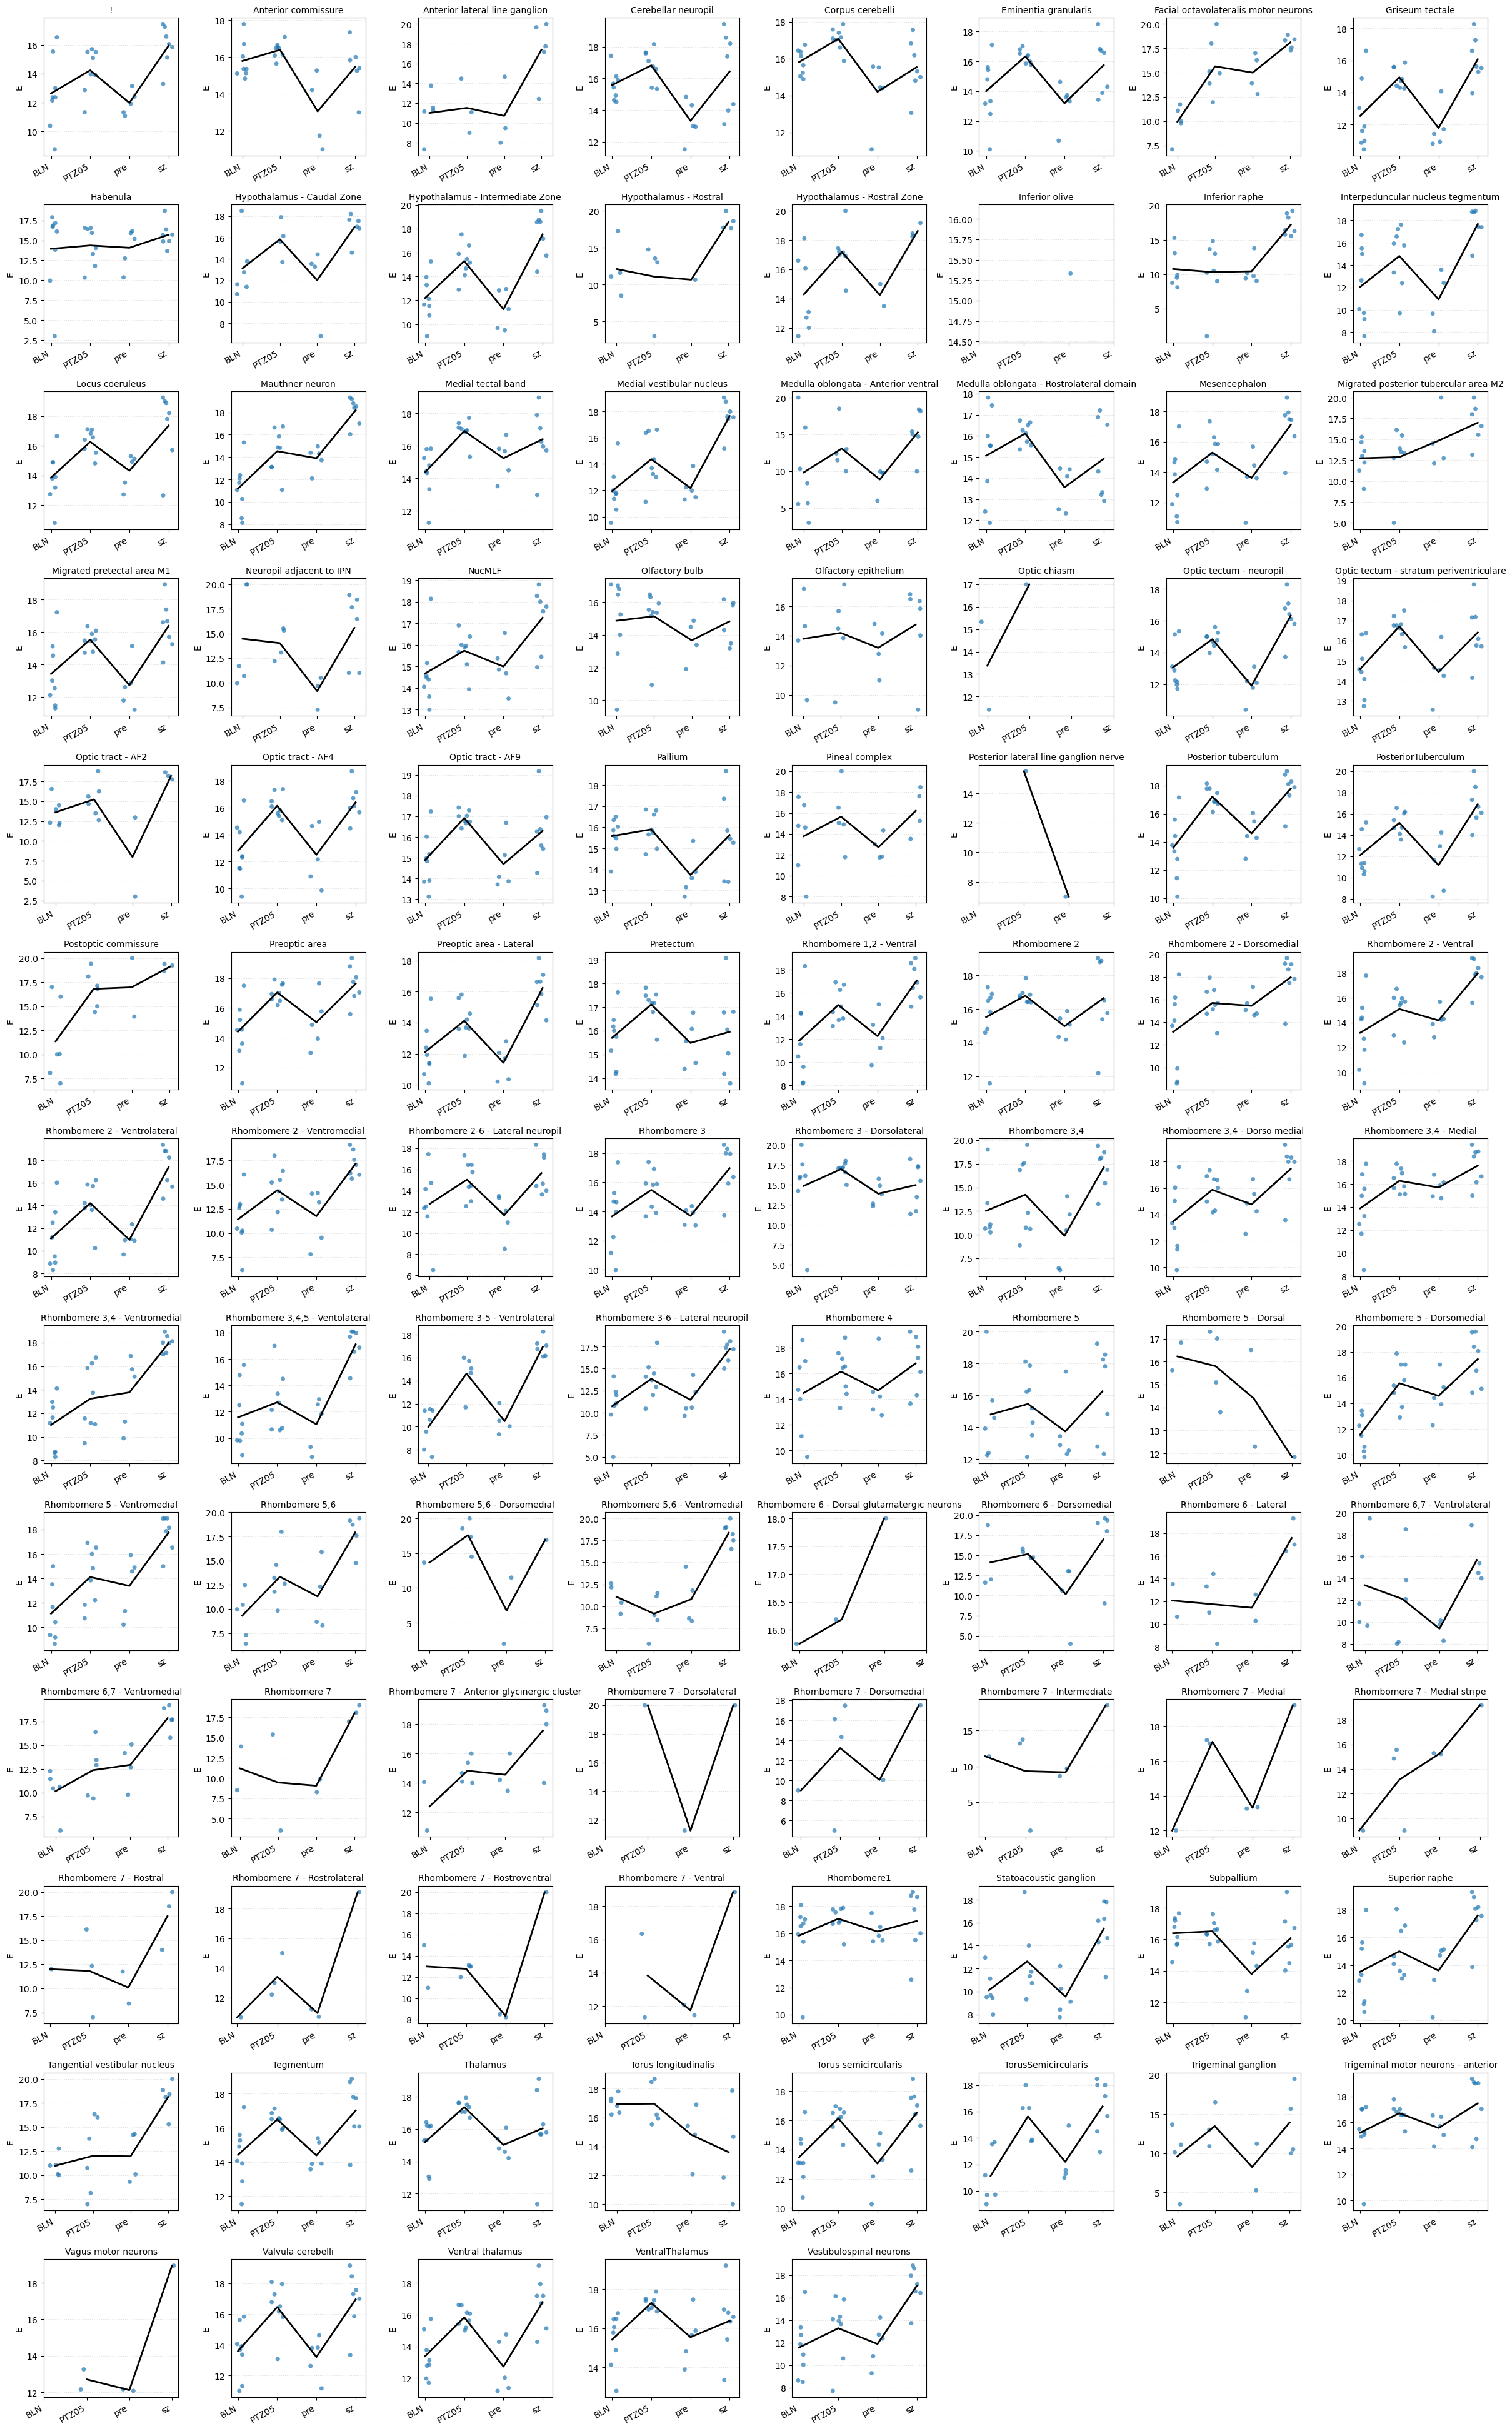

In [13]:
plot_E_by_label(fin, label_type='gran')

In [ ]:
#directionality
#rows = each cell is the effects of the current row
#columns = each cell is the causes of the current column
#(ie. cell xy = to what extent does x cause y; cell yx = to what extent does y cause x). 

In [88]:
#rho diff run
from tqdm import tqdm
%autoreload

def group(dic, reg, label):
    val = pd.DataFrame(dic['rhodiff'], columns = reg, index=reg)
    melt = (val.reset_index()
        .melt(id_vars='index', var_name='col', value_name='rhodiff')
        .rename(columns={'index': 'row'}))
    out_df = melt.groupby(['row', 'col']).mean().reset_index()
    out_df['level'] = label
    return(out_df)
    
#extract rhodiff per region + condition
#=======================================
fin = pd.DataFrame()
for data in tqdm(mask_l):
    dic = cfn.xtr(data)

    coarse_df = group(dic, dic['coord'][:,4], 'coarse')
    gran_df = group(dic, dic['coord'][:,3], 'gran')
    comb = pd.concat([coarse_df, gran_df])

    if '_sz_' in data or '_pre_' in data:cond = data.split('_')[-2]
    else:cond = data.split('_')[-3]

    comb['cond'] = cond
    comb['id'] = os.path.basename(data)
    fin=pd.concat([fin,comb])
    
fin.to_csv(f'{data_path}/rhodiff_region.csv')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [23:29<00:00, 50.34s/it]


In [131]:
fin = pd.read_csv(f'{data_path}/rhodiff_region.csv', index_col=0)
df = fin[fin['row'].values != fin['col'].values].groupby(['row', 'level', 'cond', 'id']).mean().reset_index() 
df

,row,level,cond,id,rhodiff
0,!,gran,BLN,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-0...,0.041147
1,!,gran,BLN,PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-0...,0.011742
2,!,gran,BLN,PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-0...,0.005213
3,!,gran,BLN,PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-0...,0.085559
4,!,gran,BLN,PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-0...,0.030088
...,...,...,...,...,...
2356,Vestibulospinal neurons,gran,sz,PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run...,0.154536
2357,Vestibulospinal neurons,gran,sz,PTZ-WILDTYPE-08_2photon_sess-01-6dpf_PTZ20_run...,0.110890
2358,Vestibulospinal neurons,gran,sz,PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ20_run...,0.122341
2359,Vestibulospinal neurons,gran,sz,PTZ-WILDTYPE-12_2photon_sess-01-6dpf_PTZ20_run...,0.143958


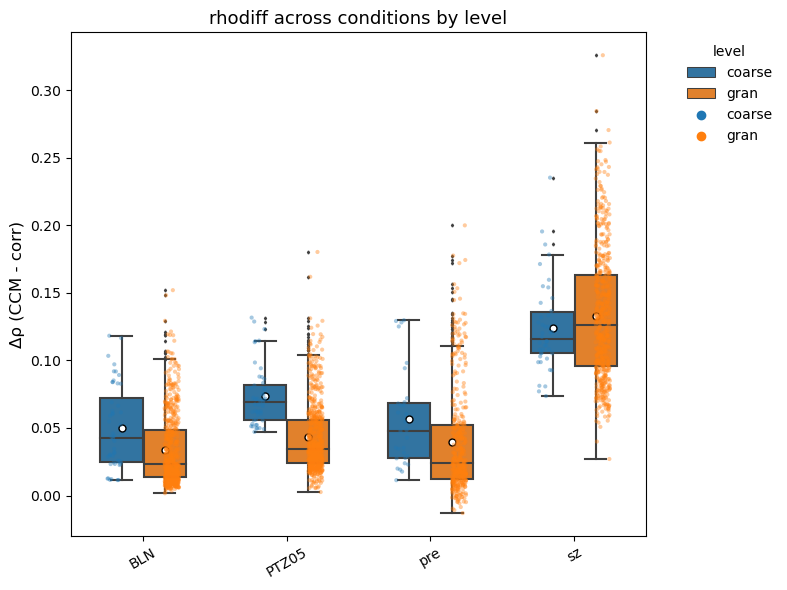

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure order consistency

order_cond = sorted(df['cond'].unique())
order_level = sorted(df['level'].unique())

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='cond', y='rhodiff',
    hue='level',
    order=order_cond,
    hue_order=order_level,
    fliersize=1.5,
    width=0.6,
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 5}
)

sns.stripplot(
    data=df,
    x='cond', y='rhodiff',
    hue='level',
    dodge=True,
    order=order_cond,
    hue_order=order_level,
    size=3, alpha=0.4
)

plt.xlabel('')
plt.ylabel('Δρ (CCM - corr)', fontsize=12)
plt.title('rhodiff across conditions by level', fontsize=13)
plt.xticks(rotation=30)
plt.legend(title='level', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

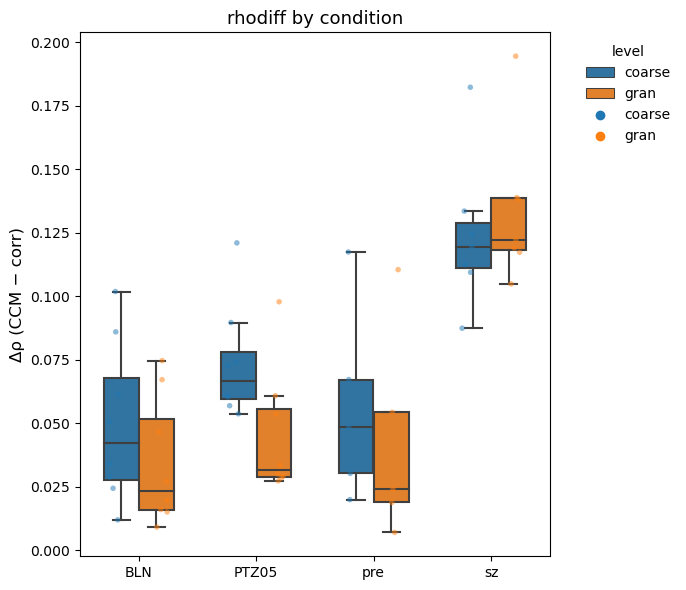


Significance vs BLN (two-sample t-test):

  coarse: PTZ05  vs BLN -> p = 0.1063
  coarse: pre    vs BLN -> p = 0.7517
  coarse: sz     vs BLN -> p = 0.0004
    gran: PTZ05  vs BLN -> p = 0.4082
    gran: pre    vs BLN -> p = 0.6946
    gran: sz     vs BLN -> p = 0.0000


In [132]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# --- Collapse across region pairs ---
df_avg = df.groupby(['id', 'cond', 'level'], as_index=False)['rhodiff'].mean()

# --- Order of conditions ---
order_cond = ['BLN', 'PTZ05', 'pre', 'sz']
order_level = sorted(df_avg['level'].unique())

# --- Plot ---
plt.figure(figsize=(7,6))

sns.boxplot(
    data=df_avg,
    x='cond', y='rhodiff',
    hue='level',
    order=order_cond,
    hue_order=order_level,
    showfliers=False, width=0.6
)
sns.stripplot(
    data=df_avg,
    x='cond', y='rhodiff',
    hue='level',
    order=order_cond,
    hue_order=order_level,
    dodge=True, size=4, alpha=0.5
)

plt.xlabel('')
plt.ylabel('Δρ (CCM − corr)', fontsize=12)
plt.title('rhodiff by condition', fontsize=13)
plt.legend(title='level', bbox_to_anchor=(1.05,1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

# --- Significance vs BLN ---
print("\nSignificance vs BLN (two-sample t-test):\n")

for lvl in df_avg['level'].unique():
    bln_vals = df_avg.loc[(df_avg['level']==lvl) & (df_avg['cond']=='BLN'), 'rhodiff']
    for cond in order_cond:
        if cond == 'BLN':
            continue
        cond_vals = df_avg.loc[(df_avg['level']==lvl) & (df_avg['cond']==cond), 'rhodiff']
        if len(cond_vals) > 1 and len(bln_vals) > 1:
            t, p = ttest_ind(cond_vals, bln_vals, equal_var=False)
            print(f"{lvl:>8s}: {cond:<6s} vs BLN -> p = {p:.4f}")

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_rhodiff_by_level(df, level_type='coarse', figsize_base=(3, 3)):
    """
    Plot rhodiff for each 'row' region (subplot),
    grouped by 'cond', with each unique id as a point.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain ['row', 'rhodiff', 'level', 'cond', 'id']
    level_type : str
        Either 'coarse' or 'gran' (filters df['level'])
    figsize_base : tuple
        Base size per subplot, scaled automatically
    """
    df_sub = df[df['level'] == level_type].copy()
    regions = sorted(df_sub['row'].unique())
    conds = ['BLN', 'PTZ05', 'pre', 'sz']  # enforce order

    n_regions = len(regions)
    ncols = 4 if level_type == 'coarse' else 8
    nrows = math.ceil(n_regions / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_base[0]*ncols, figsize_base[1]*nrows),
        squeeze=False
    )

    for i, region in enumerate(regions):
        ax = axes.flat[i]
        sub = df_sub[df_sub['row'] == region]

        rng = np.random.default_rng(0)
        xvals = sub['cond'].map({c: i for i, c in enumerate(conds)})
        jitter = rng.uniform(-0.15, 0.15, size=len(xvals))
        ax.scatter(xvals + jitter, sub['rhodiff'], s=25, alpha=0.7, edgecolors='none')

        # overlay mean per condition
        means = sub.groupby('cond')['rhodiff'].mean().reindex(conds)
        ax.plot(range(len(conds)), means.values, color='black', lw=2)

        ax.set_title(region, fontsize=9)
        ax.set_xticks(range(len(conds)))
        ax.set_xticklabels(conds, rotation=30, ha='right')
        ax.grid(axis='y', linestyle=':', alpha=0.4)
        ax.set_ylabel('Δρ (CCM − corr)')

    # hide unused axes
    for j in range(i + 1, nrows * ncols):
        fig.delaxes(axes.flat[j])

    plt.tight_layout()
    plt.show()


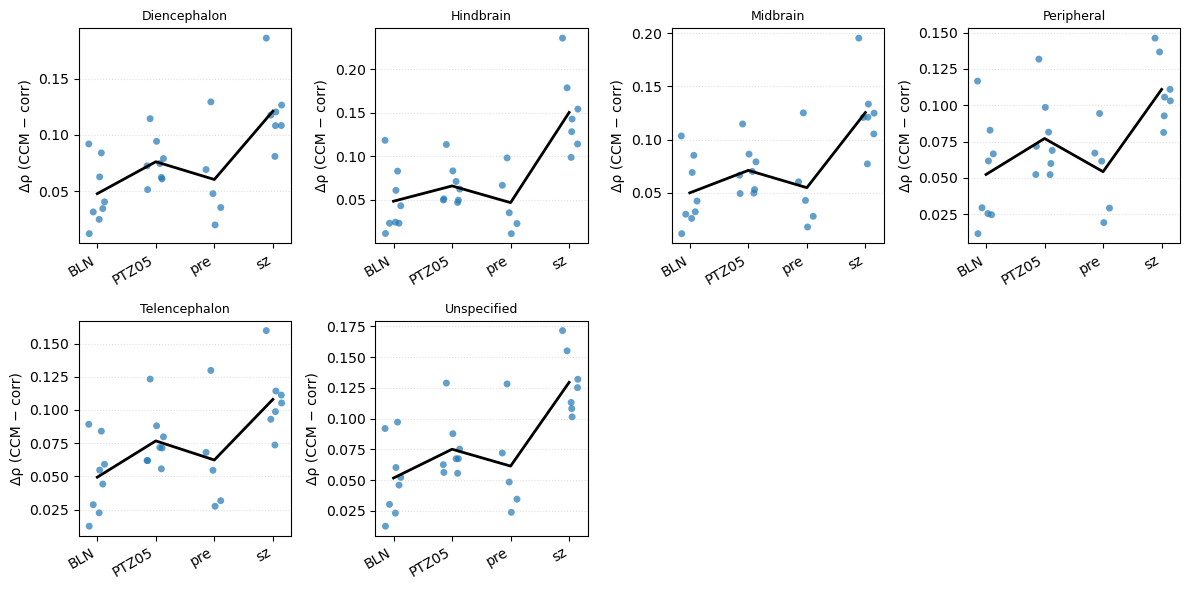

In [134]:
plot_rhodiff_by_level(df, level_type='coarse')

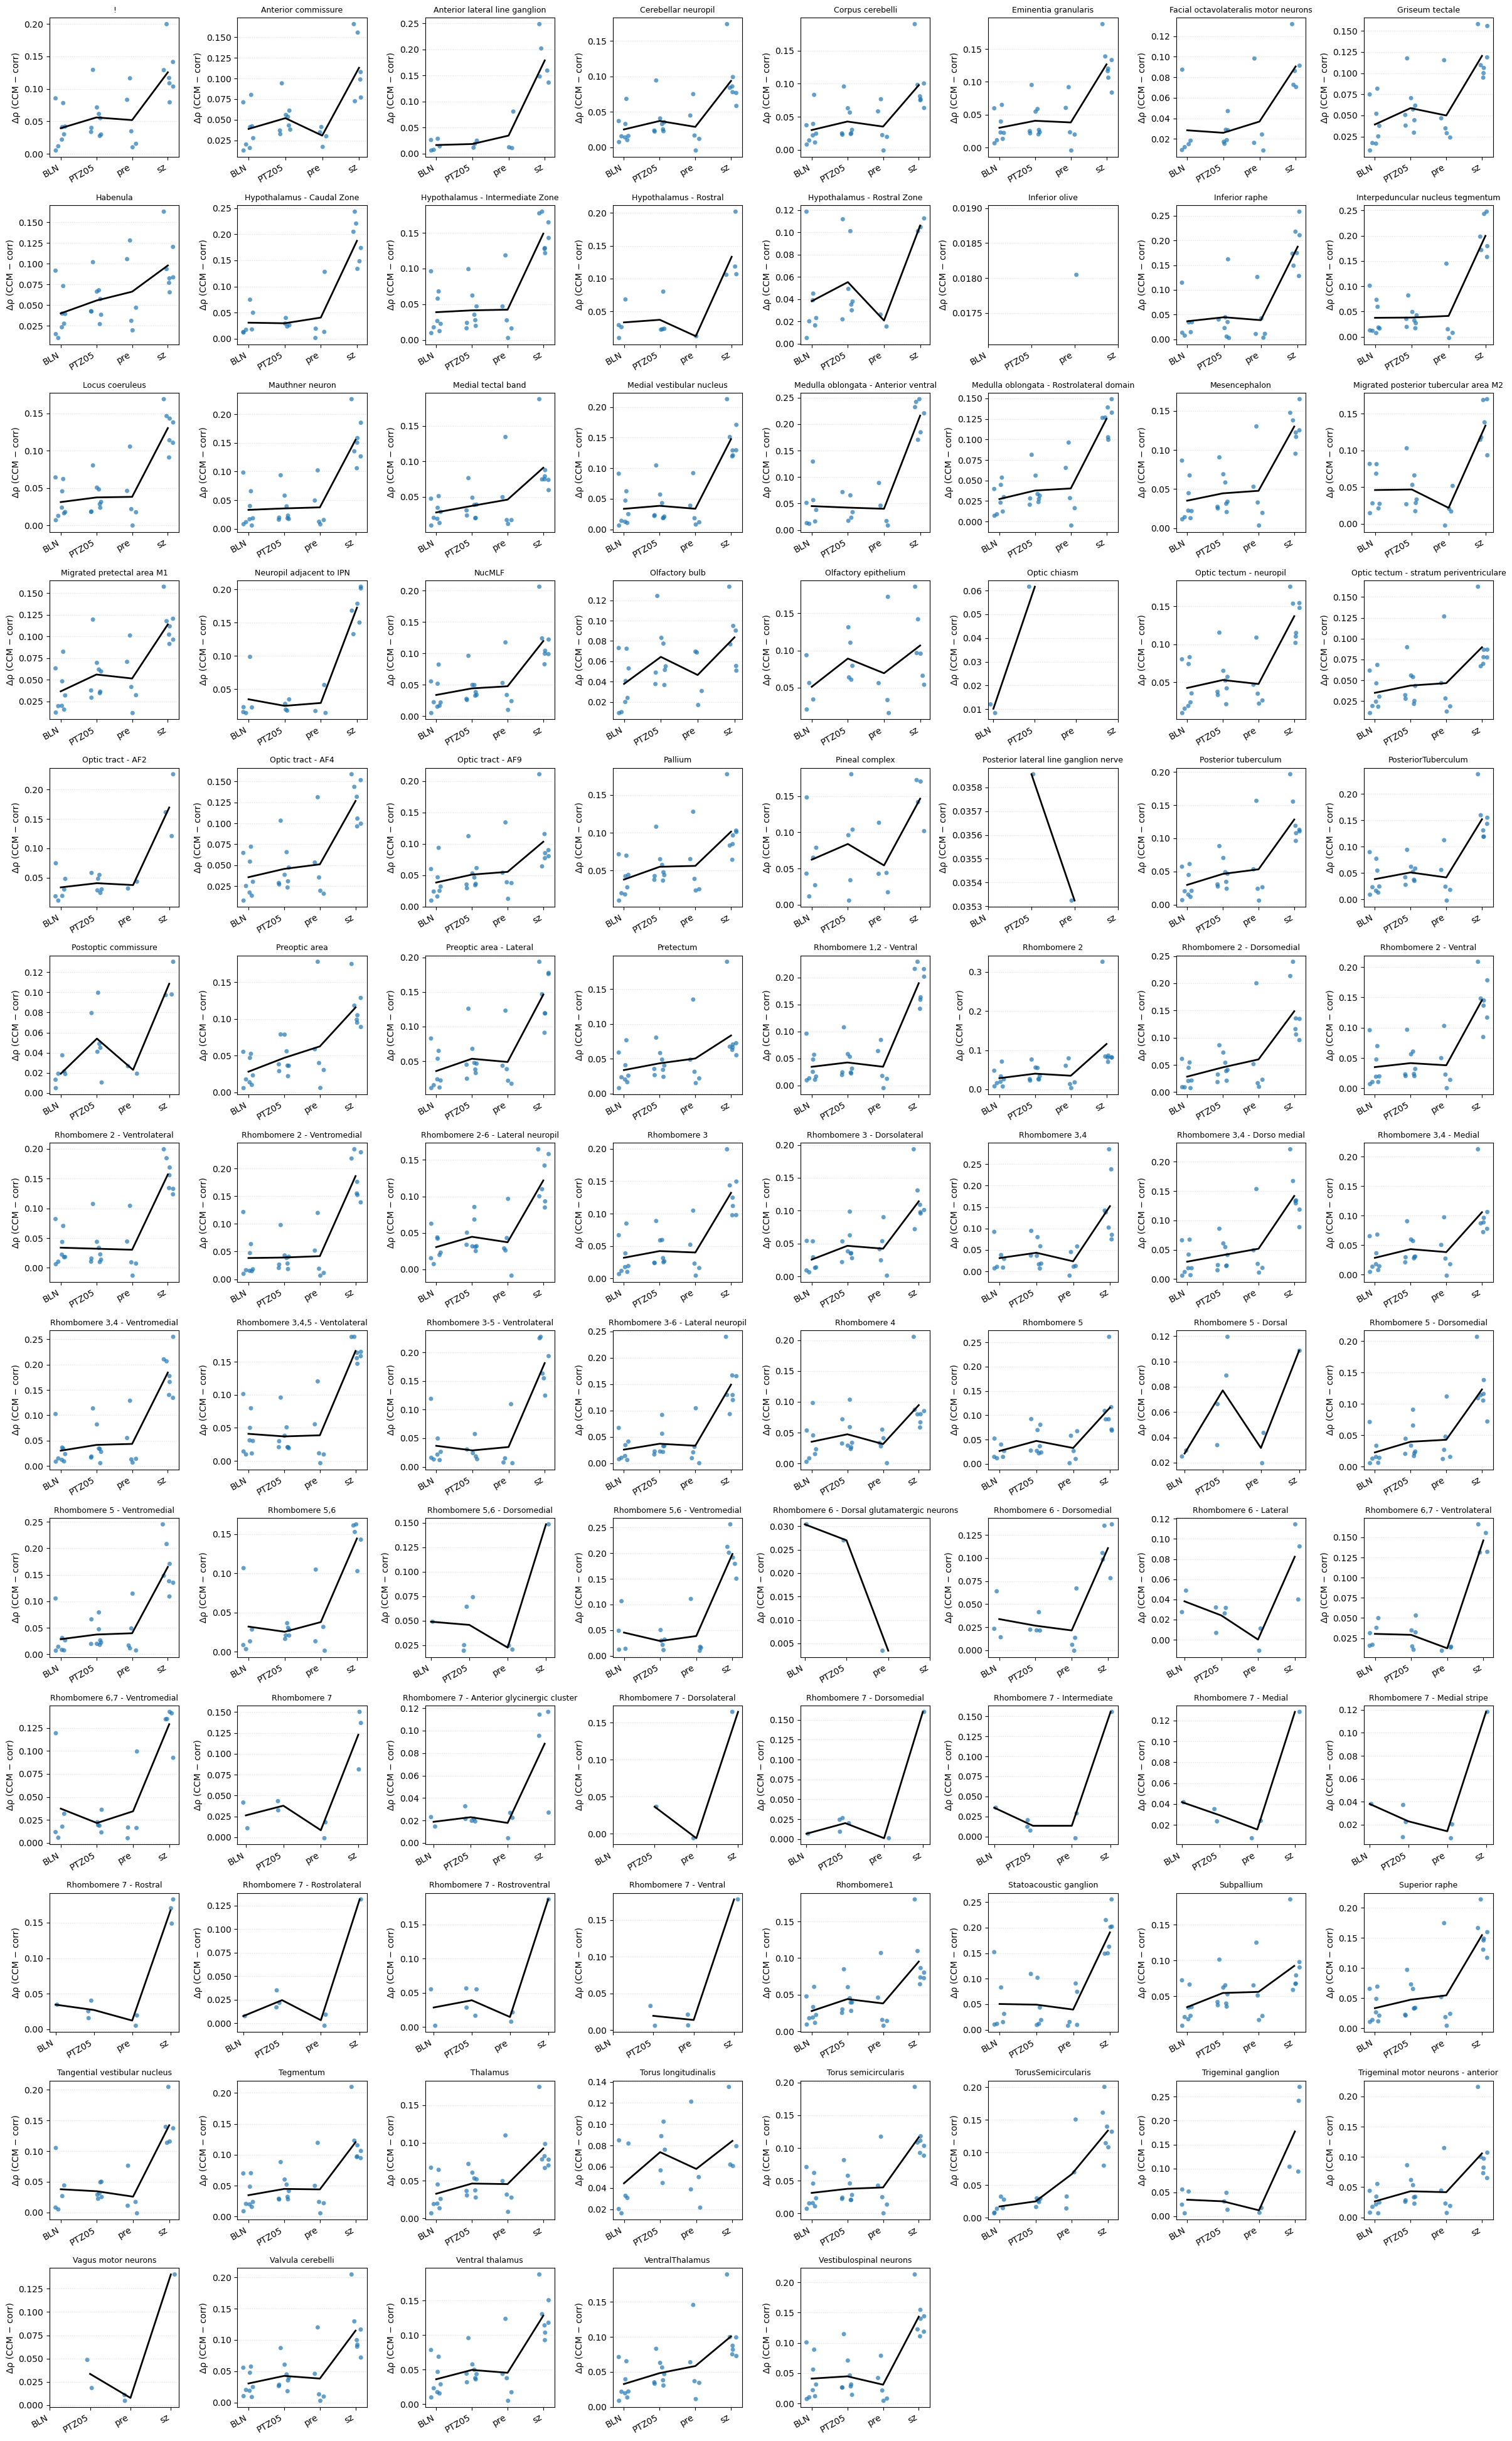

In [135]:
plot_rhodiff_by_level(df, level_type='gran')

In [146]:
# confirm -> on sparse data - e.g. subsample
#=========================================
#participation ratio

data_l, name_l, cond_l = [],[],[]
for data in tqdm(mask_l):
    dic = cfn.xtr(data)

    X = dic['trace'].T
    mu = X.mean(axis=0, keepdims=True)
    Xc = X - mu                       # correlation-PR: Xc /= X.std(axis=0, keepdims=True) + 1e-8

    from sklearn.utils.extmath import randomized_svd
    k = min(512, Xc.shape[1])         # bump k until d_PR stabilizes
    U, s, Vt = randomized_svd(Xc, n_components=k, n_iter=2, random_state=0)
    d_pr = (s**2).sum()**2 / (s**4).sum()

    if '_sz_' in data or '_pre_' in data:cond = data.split('_')[-2]
    else:cond = data.split('_')[-3]

    data_l.append(d_pr)
    name_l.append(dic['name'])
    cond_l.append(cond)


fin = pd.DataFrame({'pr':data_l, 'name': name_l, 'cond': cond_l})
fin.to_csv(f'{data_path}/participation_ratio.csv')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [01:05<00:00,  2.35s/it]


In [ ]:
# confirm -> on sparse data - e.g. subsample
#=========================================
#participation ratio - use PCA


def compute_pr(data):

    dic = cfn.xtr(data)
    X = dic['trace'].T
    scale = StandardScaler().fit_transform(X)
    pca = PCA().fit(scale)
    eigvals = pca.explained_variance_
    d_pr = (eigvals.sum()**2) / np.sum(eigvals**2)

    if '_sz_' in data or '_pre_' in data:cond = data.split('_')[-2]
    else:cond = data.split('_')[-3]
    name = dic['name']
    
    return(name, cond, d_pr)


    
    
if __name__ == "__main__":
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    n_proc = 8
    print(f"Running on {n_proc} cores...")

    with Pool(processes=n_proc) as pool:
        results = list(tqdm(pool.imap_unordered(compute_pr, mask_l), total=len(mask_l)))

    # unpack results into dataframe
    name_l, cond_l, data_l = zip(*results)
    fin = pd.DataFrame({'pr': data_l, 'name': name_l, 'cond': cond_l})
    fin.to_csv(f"{data_path}/participation_ratio_PCA.csv", index=False)
    print("Saved:", f"{data_path}/participation_ratio_PCA.csv")
    

In [171]:
eigvals

array([2.0013693e+03, 1.1357668e+03, 5.5006744e+02, ..., 7.1316324e-02,
       7.1163088e-02, 6.0425775e-11], dtype=float32)

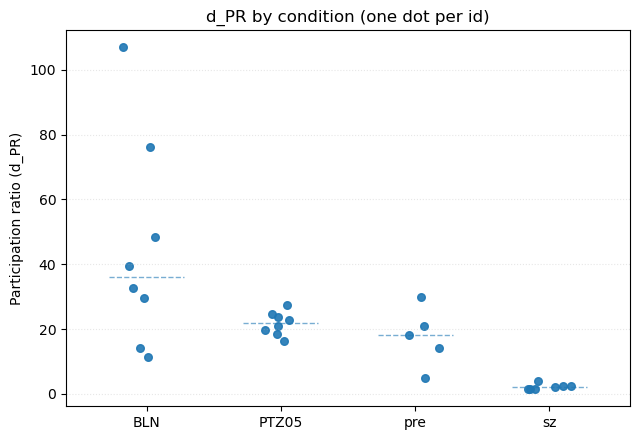

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_pr_dot(df, use_logy=False):
    # enforce one point per (name, cond)
    df1 = df.drop_duplicates(subset=['name','cond']).copy()

    # condition order
    cond_order = ['BLN', 'PTZ05', 'pre', 'sz']
    df1['cond'] = pd.Categorical(df1['cond'], categories=cond_order, ordered=True)

    # x positions per condition with jitter
    x_pos = {c: i for i, c in enumerate(cond_order)}
    jitter = 0.18
    xs = df1['cond'].map(x_pos).astype(float).values + np.random.uniform(-jitter, jitter, size=len(df1))

    # plot
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.scatter(xs, df1['pr'].values, s=30, alpha=0.9)

    # pretty x-axis
    ax.set_xticks(range(len(cond_order)))
    ax.set_xticklabels(cond_order)
    ax.set_xlim(-0.6, len(cond_order)-0.4)

    # optional: show per-condition medians
    for c, i in x_pos.items():
        sub = df1.loc[df1['cond'] == c, 'pr'].values
        if sub.size:
            med = np.median(sub)
            ax.hlines(med, i-0.28, i+0.28, linestyles='--', linewidth=1, alpha=0.6)

    ax.set_ylabel("Participation ratio (d_PR)")
    ax.set_title("d_PR by condition (one dot per id)")
    ax.grid(True, axis='y', linestyle=':', alpha=0.3)

    if use_logy:
        ax.set_yscale('log')
        ax.set_ylabel("Participation ratio (d_PR, log scale)")

    plt.tight_layout()
    plt.show()

# Usage:
plot_pr_dot(fin)            # linear y
# plot_pr_dot(df, True)      # log y

In [176]:
fin = pd.read_csv(f"{data_path}/participation_ratio_PCA.csv")
fin

,pr,name,cond
0,93.536242,PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01,PTZ05
1,348.762163,PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01,BLN
2,9.689308,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run...,sz
3,6.764649,PTZ-WILDTYPE-04_2photon_sess-01-6dpf_PTZ20_run...,sz
4,946.803009,PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01,BLN
5,158.905997,PTZ-WILDTYPE-08_2photon_sess-01-6dpf_PTZ20_run...,pre
6,5.910086,PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run...,sz
7,135.210399,PTZ-WILDTYPE-09_2photon_sess-01-6dpf_PTZ20_run...,pre
8,7.970519,PTZ-WILDTYPE-08_2photon_sess-01-6dpf_PTZ20_run...,sz
9,120.205392,PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01,BLN


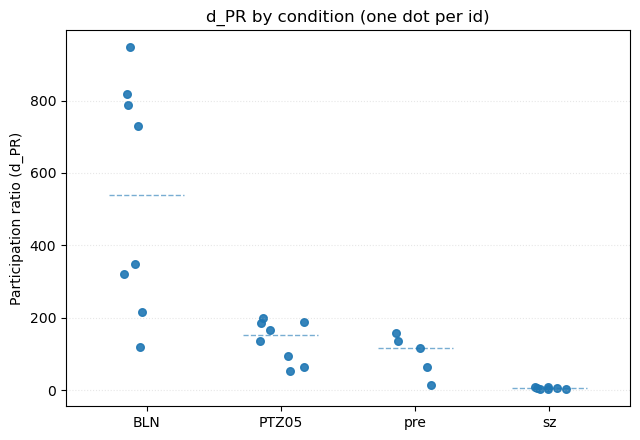

In [173]:
plot_pr_dot(fin)            # linear y
# plot_pr_dot(df, True)      # log y


In [51]:
#PR vs E
#======
pr = pd.read_csv(f'{data_path}/participation_ratio.csv', index_col=0)
e = pd.read_csv(f'{data_path}/E_region.csv', index_col=0)
e = e.groupby(['name', 'id']).mean().reset_index()
e = e.rename(columns={'name':'cond', 'id':'name'})
e['name'] = ['_'.join(i.split('_')[:-1]) for i in e['name'].values]

from scipy.stats import pearsonr

def plot_pr_vs_E(pr, e, logx=False, logy=False):
    merged = pd.merge(pr, e, on=['name', 'cond'], how='inner')
    
    # --- Define condition order and colors ---
    order_cond = ['BLN', 'PTZ05', 'pre', 'sz']
    palette = sns.color_palette("Spectral_r", len(order_cond))
    cond_colors = dict(zip(order_cond, palette))
    
    # --- Scatter plot ---
    plt.figure(figsize=(6.5, 5.5))
    sns.scatterplot(
        data=merged,
        x='pr', y='E',
        hue='cond',
        hue_order=[c for c in order_cond if c in merged['cond'].unique()],
        palette=cond_colors,
        s=70, alpha=0.8, edgecolor='none'
    )
    
    if logx: plt.xscale('log')
    if logy: plt.yscale('log')
    
    plt.xlabel("Participation ratio (PR)", fontsize=12)
    plt.ylabel("Embedding dimension (E)", fontsize=12)
    plt.title("PR vs E by condition", fontsize=13)
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    plt.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.show()
    
    # --- Significance testing (Pearson r) ---
    print("\nCorrelation (r) and significance (p-value) between PR and E per condition:\n")
    for c in merged['cond'].unique():
        sub = merged.loc[merged['cond'] == c]
        if len(sub) > 2:
            r, p = pearsonr(sub['pr'], sub['E'])
            sig = " **" if p < 0.05 else ""
            print(f"{c:<6s}: r = {r:6.3f}, p = {p:.4e}{sig}")
        else:
            print(f"{c:<6s}: not enough samples")


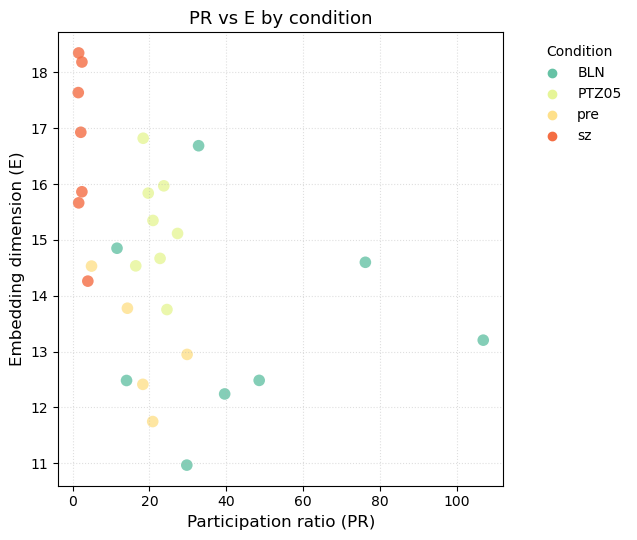


Correlation (r) and significance (p-value) between PR and E per condition:

BLN   : r =  0.013, p = 9.7596e-01
PTZ05 : r = -0.290, p = 4.8600e-01
sz    : r = -0.669, p = 1.0021e-01
pre   : r = -0.677, p = 2.0928e-01


In [52]:
plot_pr_vs_E(pr, e,logx=False, logy=False)

In [ ]:
#theory
#majority of dynamics can be described with few correlated modes
#but something else is happening
#each neuron receives a large number of inputs

In [ ]:
# effect of coarse graining on E & non-lin

# cluster CCM with k clusters -> 10

# format for CCM 

# run rhodiff + E

# compare

#compare -> effect of coarse graining

In [ ]:
# tease apart lin vs non-lin effects

In [ ]:
#visualise linear vs non-linear networks

#what are you trying to visualise? 

In [ ]:
# correlation vs not correlation -> explain this difference??? 